# Kinetics Analysis Tutorial

This tutorial guides you through analyzing timeseries fluorescence data from _in vitro_ protein expression experiments. We'll cover data loading, normalization, visualization, kinetic parameter fitting, and summary statistics.

## Table of Contents
1. [Setup and Import](#setup)
2. [Load Data](#load-data)
3. [Plot Raw Curves](#plot-curves)
4. [Normalize Data](#normalize)
5. [Kinetic Analysis](#kinetic-analysis)
6. [Summary Plots](#summary)

---

## 1. Setup

First, import the necessary libraries and set up the plotting environment.

The custom `platereader` module that contains specialized functions for loading plate reader data, performing kinetic analysis, and visualization. The `plot_setup()` function configures matplotlib for time-series plots.

In [24]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## 2. Load Data

Load your plate reader data and merge it with the platemap that describes experimental conditions.

- `data_file` is the location of your platereader data (ideally in biotek-cdk format)
- `platemap_file`: location of your platemap CSV with Well and experimental conditions
- `load_platereader_data()` reads your plate reader output file and parses it into a standardized format with the platemap integrated
- The resulting DataFrame contains columns: `Date`, `Experiment`, `Plate`, `Well`, `Row`, `Column`, `Time`, `Read`, `Data`, plus any columns from your platemap
- `Data` column contains fluorescence measurements
- `Time` representing elapsed time

In [25]:
# Specify file paths
data_file = "cytation5-pure-timecourse-gfp-biotek-cdk.txt"
platemap_file = "platemap.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   Time                         576 non-null    timedelta64[ns]
 1   Well                         576 non-null    object         
 2   Data                         576 non-null    float64        
 3   Row                          576 non-null    object         
 4   Column                       576 non-null    int64          
 5   Read                         576 non-null    object         
 6   Plate                        576 non-null    object         
 7   Clock Time                   576 non-null    datetime64[ns] 
 8   Date                         576 non-null    object         
 9   Experiment                   576 non-null    object         
 10  Name                         576 non-null    object         
 11  Type                         576

---

## 3. Plot Raw Curves

Visualize the time-series fluorescence data to inspect curve shapes and identify any issues.

- `plot_curves_by_name()` creates line plots with time on x-axis and fluorescence (Data) on y-axis
- Each line represents one well, colored by the `Name` column (experimental condition)
- If you have multiple gain data, they'll be plotted in separate subplots (but you should choose one to move forward with)
- This visualization helps you spot outliers, failed reactions, or unexpected kinetics before fitting

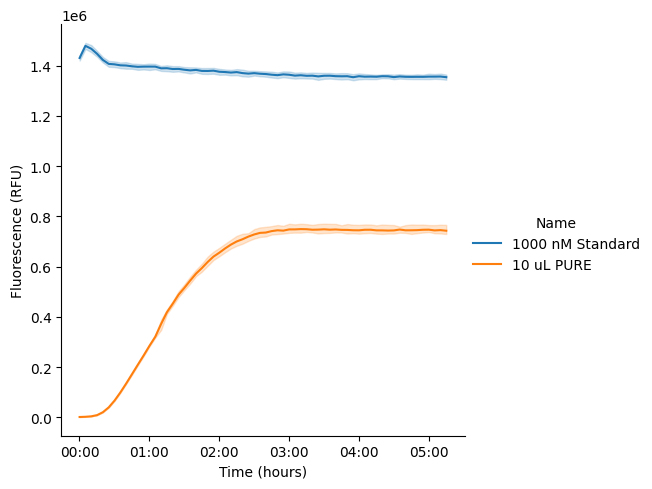

In [26]:
g = pr.plot_curves(data=data, y="Data")

---

## 4. Normalize Data

Normalize your data to an internal fluorescence sample so that you have relative fluorescence to compare to other experiments. 

In [27]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1000 nM Standard')

Data Normalized to 1000 nM Standard in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

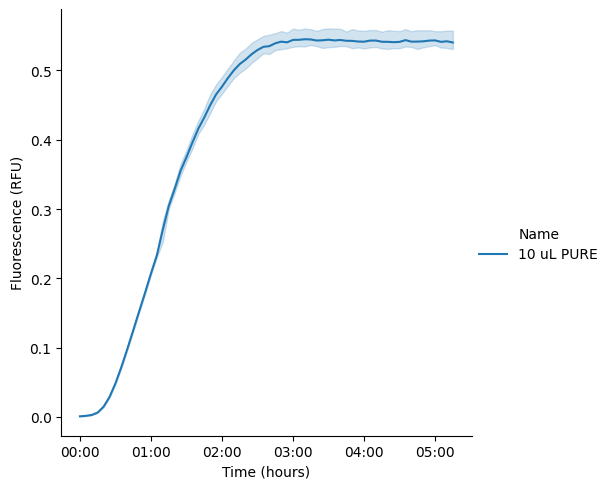

In [28]:
g = pr.plot_curves(data=data)

---

## 5. Kinetic Analysis

Fit sigmoid curves to the data to extract kinetic parameters: maximum reaction rate ($V_\text{max}$), lag time, steady-state fluorescence, and drift.

`kinetic_analysis()` fits a **logistic curve** (with optional drift term) to each replicate well. 
$$
F(t) = F_\text{ss}\frac{1}{1 + e^{-k(t-\tau_\text{vel})}} + d(t- \tau_\text{drift}), 
$$

with the following parameters:
| Fit Parameter | Name | Units | What it tells you |
|---|---|---|---|
|$F_\text{ss}$ | Steady-State Fluorescence | $u$ | Fluorescence at completion of the reaction. Proportional to total amount of reporter expressed. |
| $k$ | Steepness | unitless | How fast is the reaction? |
| $\tau_\text{vel}$  | Inflection Time | $h$ | How long until the reaction reaches its fastest rate? |
| $d$ | Drift Rate | $u \cdot h^{-1}$| The rate of drift after steady state (ideally, close to zero). |
| $\tau_\text{drift}$| Drift Onset Time | $h$ | When does drift start to affect fluorescence? |


**Metrics extracted:**
- **Maximum reaction rate ($V_\text{max}$):**  the maximum slope of the sigmoid, which occurs at $\tau_\text{vel}$ and equals $\frac{F_\text{ss} \cdot k}{4}$. This is *not* the Michaelis–Menten $V_\text{max}$. Use $\frac{F_\text{ss} \cdot k}{4}$ for downstream calculations that require a slope with units ($u \cdot h^{-1}$). When comparing reaction rates across conditions, use $k$ instead.
- **Lag time ($\tau_\text{lag}$):** the time it takes for the reaction to "start" (units of $h$). Explicitly, the x-intercept of the line tangent to the inflection point ($\tau_{vel}$) on the sigmoid. This is metric is related to transcription lag time, translation lag time, and the maturation time of your reporter. 
- **Time-to-completion ($\tau_\text{ss}$):** the time at which the reaction is "finished" (units of $h$). Explicitly, when the sigmoid reaches a chosen fraction $\alpha$ of its asymptote (default $\alpha=0.95$). $\tau_\text{ss}$ can be derived analytically from the model as
  $$
  \tau_\text{ss} \;=\; t_0 + \frac{1}{k}\ln\!\left(\frac{\alpha}{1-\alpha}\right).
  $$
- **R²**: Goodness of fit

In [29]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics

PROVIDING AVERAGED KINETICS


Velocity                       \
                                Time data_normalized  Max   
Name                                                        
10 uL PURE 0 days 01:08:27.217292285            0.27 0.37   

                                 Lag                  \
                                Time data_normalized   
Name                                                   
10 uL PURE 0 days 00:24:31.819530137            0.04   

                        Steady State                  \
                                Time data_normalized   
Name                                                   
10 uL PURE 0 days 02:13:07.101239612            0.52   

                                                          Fit             
                                                       params  R^2 drift  
Name                                                                      
10 uL PURE  [0.5461084779531747, 2.7323118387903667, 1.140... 1.00  0.01

### Visualize Fits on Individual Wells

**What's happening:**
- `plot_kinetics_by_well()` overlays fitted curves and kinetic parameters on raw data
- Visual inspection ensures fits are reasonable (high R², smooth curves)
- Annotations show where Vmax, lag time, and steady-state occur

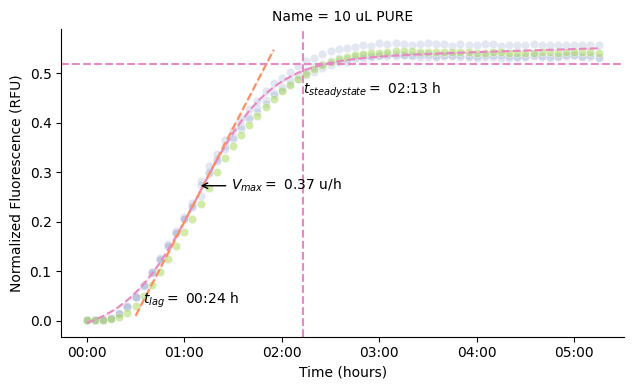

In [30]:
#| label: fig:kinetics

# Plot kinetic fits
sample = data[data["Type"] == "Sample"]
g, kinetics = pr.plot_kinetics(sample, kinetics=kinetics, group_by=["Name"])
plt.savefig("../assets/thumbnail.png")

---

## 6. Summary Plots

Compare kinetic parameters across experimental conditions. The `plot_kinetics_summary()` function creates a comprehensive multi-panel figure with raw curves, steady-state fluorescence, $V_\text{max}$, and drift rate. Error bars show std across technical replicates

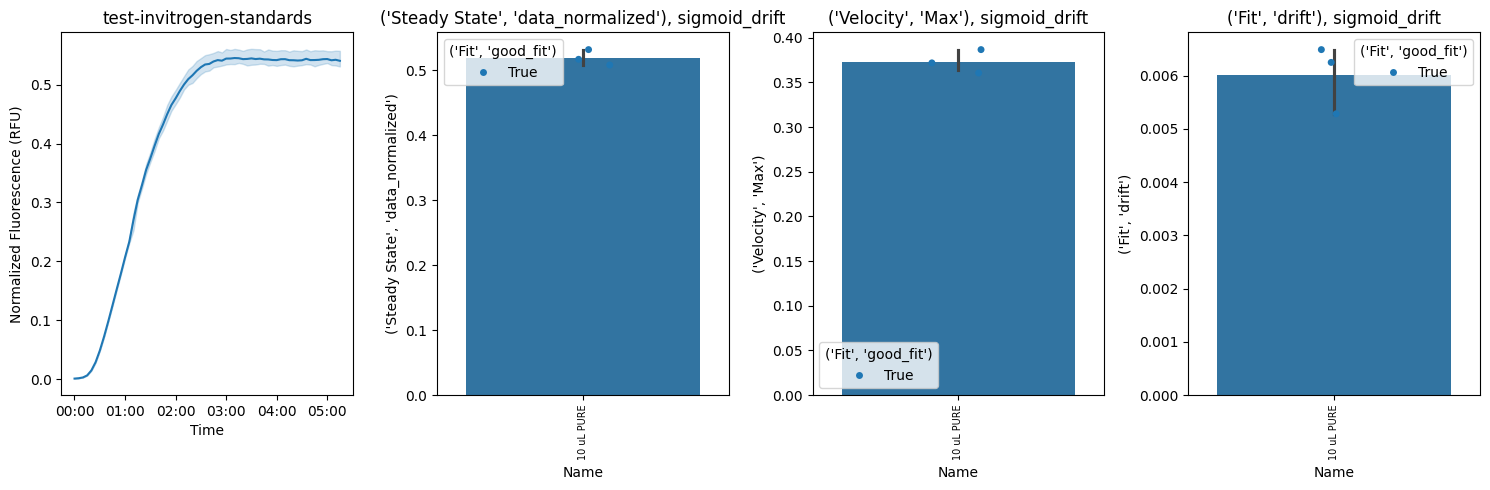

In [31]:
pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Fluorescence**
- The fluorescence value reached at the completion of the reaction, with units: fluorescence units (e.g., a.u., RFU, $\mu$M GFP, etc.).
- Proxy for the total amount of protein produced. Higher values indicate greater expression yield.
- Estimated as the asymptotic behavior of the logistic curve (ignoring drift).

### 2. **Maximum Velocity**
- The steepest slope of the fluorescence curve (at the inflection point), with units: fluorescence units per time.
- Reflects the peak rate of protein synthesis.
- Sensitive to enzyme activity, substrate availability, and reaction conditions.

### 3. **Lag Time**
- Time before exponential fluorescence increase begins, with units: time.
- May reflect time for initial reaction steps (e.g., transcription, ribosome assembly, etc.).
- Shorter lag times suggest faster reaction initiation.

### 4. **Drift**
- Rate of fluorescence change after reaching steady-state, with units: fluorescence units per time.
- Positive drift: continued synthesis or aggregation, evaporation.
- Negative drift: photobleaching, protein degradation, or quenching

### 5. **R² Value**
- Goodness of fit (0 to 1, higher is better), with units: unitless.
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants